# BUSINESS DATA ANALYTICS APPLIED LAB #1  
## RESTAURANT ANALYTICS - WEEK 2

**Asignatura:** Data Analytics (Código: 43390860)  
**Semana:** 2 - Perfil del analista, modelo relacional y trabajo reproducible

### Contexto de negocio

Usted ha sido contratado como **Business Data Analyst** por una cadena de restaurantes que conserva sus datos de productos, clientes y ventas en cuatro archivos independientes. La gerencia conoce cuánto vende, pero no puede comparar las dos semanas, identificar los productos que generan más ingresos ni estimar la recurrencia de sus clientes.

Su misión es consolidar las fuentes, validar las uniones y construir indicadores que apoyen decisiones sobre el menú y la fidelización. El proceso debe quedar documentado en un repositorio y resumido en un informe ejecutivo de una página.

> **Alcance del análisis.** Los archivos contienen precios de venta, pero no costos, cantidades ni descuentos. Por tanto, analice ingresos, frecuencia de compra y recurrencia; no rentabilidad, utilidad o margen.

## Organización mínima del trabajo reproducible

Antes de comenzar, organice su trabajo con una estructura sencilla:

```text
lab-restaurant/
│
├── data/
├── lab_Sem2_DA.ipynb
└── README.md
```

- `data/`: contiene los archivos CSV del laboratorio.
- `lab_Sem2_DA.ipynb`: notebook ejecutado.
- `README.md`: objetivo, datos utilizados, instrucciones de ejecución y principales hallazgos.

> **Criterio de reproducibilidad:** al finalizar, el notebook debe poder ejecutarse nuevamente desde la primera hasta la última celda sin modificar manualmente el código, salvo la carga inicial de los archivos si trabaja en Google Colab.


## 1. Conociendo las fuentes de datos

Trabajará con cuatro archivos:

1. `Restaurant-Foods.csv`: catálogo de productos y precios.
2. `Restaurant-Customers.csv`: información de clientes.
3. `Restaurant-Week1-Sales.csv`: registros de venta de la semana 1.
4. `Restaurant-Week2-Sales.csv`: registros de venta de la semana 2.

Antes de unir las tablas, identifique qué representa una fila en cada archivo y cuáles columnas permiten relacionarlas.

In [ ]:
# Paso 1: Carga de librerías y archivos
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

foods = pd.read_csv('Restaurant-Foods.csv')
customers = pd.read_csv('Restaurant-Customers.csv')
week1 = pd.read_csv('Restaurant-Week1-Sales.csv')
week2 = pd.read_csv('Restaurant-Week2-Sales.csv')

# Identificar la semana de cada registro de venta
week1['Semana'] = 1
week2['Semana'] = 2
all_sales = pd.concat([week1, week2], ignore_index=True)

In [ ]:
# Paso 2: Inspección inicial de las tablas
print('foods:', foods.shape)
print('customers:', customers.shape)
print('week1:', week1.shape)
print('week2:', week2.shape)

display(foods.head(3))
display(week1.head(3))

# Por privacidad, no se muestran nombres de clientes.
print('Columnas de customers:', list(customers.columns))

foods: (10, 3)
customers: (1000, 6)
week1: (250, 3)
week2: (250, 3)


,Food ID,Food Item,Price
0,1,Sushi,3.99
1,2,Burrito,9.99
2,3,Taco,2.99


,Customer ID,Food ID,Semana
0,537,9,1
1,97,4,1
2,658,1,1


Columnas de customers: ['ID', 'First Name', 'Last Name', 'Gender', 'Company', 'Occupation']


### Claves y relaciones

- `Food ID` identifica cada producto en `foods`.
- `ID` identifica cada cliente en `customers`.
- `Food ID` en las ventas referencia al producto comprado.
- `Customer ID` en las ventas referencia al cliente.

Por tanto:

- un producto puede aparecer en muchos registros de venta;
- un cliente puede aparecer en muchos registros de venta.

Antes de hacer un `merge`, conviene comprobar que las claves principales sean únicas y que las referencias existan.

### Esquema relacional mínimo

```text
CUSTOMERS
   ID
    │
    │ 1 : N
    ▼
  SALES
   ▲
   │ N : 1
   │
 FOODS
Food ID
```

Interpretación:

- un cliente puede aparecer en varios registros de venta;
- un producto puede aparecer en varios registros de venta;
- cada registro de venta referencia a un único cliente y a un único producto.


In [ ]:
# Paso 3: Validación de estructura, claves y referencias
assert foods['Food ID'].is_unique, 'Food ID debe ser único en foods'
assert customers['ID'].is_unique, 'ID debe ser único en customers'

assert all_sales['Food ID'].isin(foods['Food ID']).all(), \
    'Existen ventas con Food ID sin correspondencia'

assert all_sales['Customer ID'].isin(customers['ID']).all(), \
    'Existen ventas con Customer ID sin correspondencia'

print('Claves y referencias validadas correctamente.')

Claves y referencias validadas correctamente.


## 2. Consolidación de información

La tabla de ventas contiene identificadores. Para interpretarlos, debemos relacionarlos con los catálogos de productos y clientes.

El parámetro `validate='many_to_one'` permite comprobar que cada identificador de venta corresponda a un único registro en la tabla de referencia.

### Antes de ejecutar la unión: haga una predicción

Sin ejecutar todavía el siguiente bloque, responda:

> **¿Cuántas filas espera encontrar en `full_report` después de realizar las dos uniones? ¿Por qué?**

Escriba su respuesta en la siguiente celda.


**Mi predicción:**  

- Número esperado de filas:  500
- Justificación: 500 filas porque reúne los 250 registros de ventas de la semana 1 y los 250 registros de la semana 2. Al realizar la suma, cada venta corresponde a un único producto y a un único cliente.  


In [ ]:
# Paso 4: Consolidación de información
full_report = (
    all_sales
    .merge(
        foods,
        on='Food ID',
        how='left',
        validate='many_to_one'
    )
    .merge(
        customers,
        left_on='Customer ID',
        right_on='ID',
        how='left',
        validate='many_to_one'
    )
)

# La unión no debería crear ni eliminar registros de venta
print('Registros antes de unir:', len(all_sales))
print('Registros después de unir:', len(full_report))

assert len(full_report) == len(all_sales), \
    'La unión modificó inesperadamente el número de registros'

# Comprobar que las uniones no dejaron datos esenciales vacíos
assert full_report['Price'].notna().all(), \
    'Existen ventas sin precio asociado'

assert full_report['Occupation'].notna().all(), \
    'Existen ventas sin ocupación asociada'

print('Consolidación validada.')

Registros antes de unir: 500
Registros después de unir: 500
Consolidación validada.


## 3. Construcción de indicadores comerciales

En este conjunto de datos, cada fila corresponde a un **registro de venta**. Como no existe una columna de cantidad, contar filas permite analizar **frecuencia de compra**, pero no unidades vendidas.

Construiremos indicadores de:

- ingresos registrados;
- número de registros de venta;
- ingreso promedio por registro;
- frecuencia de compra por producto;
- recurrencia de clientes;
- ingresos agregados por ocupación.

In [ ]:
# Paso 5: Construcción de indicadores (KPIs)
full_report['Ingresos'] = full_report['Price']

total_revenue = full_report['Ingresos'].sum()

weekly_summary = (
    full_report
    .groupby('Semana')
    .agg(
        Registros_Venta=('Customer ID', 'count'),
        Ingresos=('Ingresos', 'sum'),
        Ingreso_Promedio=('Ingresos', 'mean')
    )
)

top_foods = (
    full_report
    .groupby('Food Item')
    .agg(
        Frecuencia_Compra=('Customer ID', 'count'),
        Ingresos_Totales=('Ingresos', 'sum')
    )
    .sort_values('Ingresos_Totales', ascending=False)
)

print('Ingresos totales:', total_revenue)
display(weekly_summary)
display(top_foods.head())

Ingresos totales: 3886.56


,Registros_Venta,Ingresos,Ingreso_Promedio
Semana,,,
1,250,1962.68,7.85072
2,250,1923.88,7.69552


,Frecuencia_Compra,Ingresos_Totales
Food Item,,
Steak,50,1249.50
Pasta,54,755.46
Burrito,57,569.43
Salad,48,540.00
Quesadilla,49,208.25


### Lectura de resultados antes de graficar

Observe la tabla `top_foods` y responda:

1. ¿Cuál es el producto con mayor **frecuencia de compra**?
2. ¿Cuál es el producto con mayores **ingresos**?
3. ¿Coinciden ambos productos?
4. Si no coinciden, ¿qué interpretación comercial preliminar haría?

> No avance al gráfico hasta haber respondido estas preguntas.


**Respuesta:**  

1. Burrito, con una frecuencia de compra de 57
2. Steak, con ingresos totales de 1249.50.
3. No coinciden. El Burrito es el producto con mayor frecuencia de compra,     mientras que el Steak es el que genera mayores ingresos.
4. Esto indica que una mayor frecuencia de compra no necesariamente significa mayores ingresos. Aunque el Burrito aparece más veces en los registros de venta, el Steak genera más ingresos debido a su mayor precio por venta.


In [ ]:
# Paso 6: Recurrencia de clientes
customers_w1 = set(week1['Customer ID'])
customers_w2 = set(week2['Customer ID'])

returning_customers = customers_w1.intersection(customers_w2)

# De los clientes observados en la semana 1,
# ¿qué porcentaje volvió a aparecer en la semana 2?
recurrence_rate = (
    len(returning_customers)
    / week1['Customer ID'].nunique()
    * 100
)

print('Clientes únicos semana 1:', week1['Customer ID'].nunique())
print('Clientes únicos semana 2:', week2['Customer ID'].nunique())
print('Clientes recurrentes:', len(returning_customers))
print(f'Tasa de recurrencia: {recurrence_rate:.1f}%')

Clientes únicos semana 1: 221
Clientes únicos semana 2: 224
Clientes recurrentes: 46
Tasa de recurrencia: 20.8%


In [ ]:
# Paso 7: Ingresos acumulados por ocupación (análisis agregado)
occupation_spend = (
    full_report
    .groupby('Occupation')['Ingresos']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

display(occupation_spend.to_frame('Ingresos'))

,Ingresos
Occupation,
Compensation Analyst,116.68
Sales Representative,104.18
Marketing Manager,99.40
Cost Accountant,80.21
Assistant Media Planner,72.69


## 4. La misma pregunta con SQL

Hasta este punto utilizó Pandas. Ahora obtenga el resumen semanal mediante SQL y compare los resultados.

El objetivo no es aprender dos soluciones diferentes de memoria, sino reconocer que **Pandas y SQL pueden responder la misma pregunta analítica**.

In [ ]:
# Paso 8: Cargar la tabla consolidada en una base SQLite temporal
connection = sqlite3.connect(':memory:')
full_report.to_sql(
    'ventas',
    connection,
    if_exists='replace',
    index=False
)

query = '''
SELECT
    Semana,
    COUNT(*) AS Registros_Venta,
    SUM(Price) AS Ingresos,
    AVG(Price) AS Ingreso_Promedio
FROM ventas
GROUP BY Semana
ORDER BY Semana;
'''

weekly_summary_sql = pd.read_sql_query(query, connection)

print('Resumen con Pandas')
display(weekly_summary.reset_index())

print('Resumen con SQL')
display(weekly_summary_sql)

Resumen con Pandas


,Semana,Registros_Venta,Ingresos,Ingreso_Promedio
0,1,250,1962.68,7.85072
1,2,250,1923.88,7.69552


Resumen con SQL


,Semana,Registros_Venta,Ingresos,Ingreso_Promedio
0,1,250,1962.68,7.85072
1,2,250,1923.88,7.69552


### Intervención mínima en SQL

La consulta anterior ordena las semanas cronológicamente. Ahora modifíquela para que los resultados queden ordenados de **mayor a menor ingreso**.

Cambie únicamente la cláusula `ORDER BY` y ejecute nuevamente la consulta.


In [ ]:
# TODO: modifique únicamente ORDER BY para ordenar de mayor a menor ingreso
query_ingresos = '''
SELECT
    Semana,
    COUNT(*) AS Registros_Venta,
    SUM(Price) AS Ingresos,
    AVG(Price) AS Ingreso_Promedio
FROM ventas
GROUP BY Semana
ORDER BY Semana;
'''

weekly_summary_sql_ordenado = pd.read_sql_query(
    query_ingresos,
    connection
)

display(weekly_summary_sql_ordenado)


,Semana,Registros_Venta,Ingresos,Ingreso_Promedio
0,1,250,1962.68,7.85072
1,2,250,1923.88,7.69552


### Pregunta de control

Compare las dos tablas anteriores:

> ¿Los resultados obtenidos con Pandas y SQL son consistentes? Si encuentra una diferencia, revise el código antes de continuar.

R/T: Sí, los resultados obtenidos con Pandas y SQL son consistentes. Ambas herramientas muestran los mismos registros de venta, ingresos e ingreso promedio para cada semana.

## 5. Visualización para el informe ejecutivo

Primero compare **frecuencia de compra** e **ingresos por producto**. Son indicadores relacionados, pero no equivalentes: un producto puede aparecer muchas veces y no ser el que más ingresos genera.

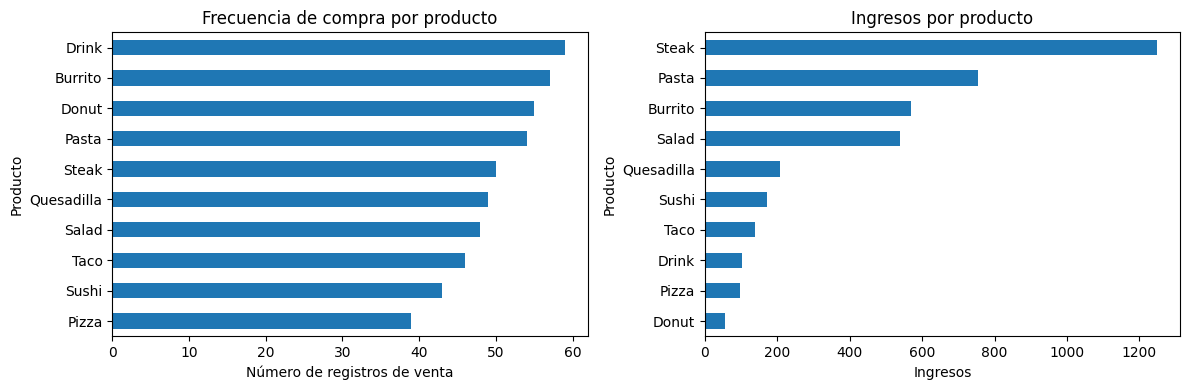

In [ ]:
# Paso 9: Desempeño del menú
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

top_foods.sort_values('Frecuencia_Compra').plot(
    kind='barh',
    y='Frecuencia_Compra',
    ax=axes[0],
    legend=False,
    title='Frecuencia de compra por producto'
)
axes[0].set_xlabel('Número de registros de venta')
axes[0].set_ylabel('Producto')

top_foods.sort_values('Ingresos_Totales').plot(
    kind='barh',
    y='Ingresos_Totales',
    ax=axes[1],
    legend=False,
    title='Ingresos por producto'
)
axes[1].set_xlabel('Ingresos')
axes[1].set_ylabel('Producto')

plt.tight_layout()
plt.show()

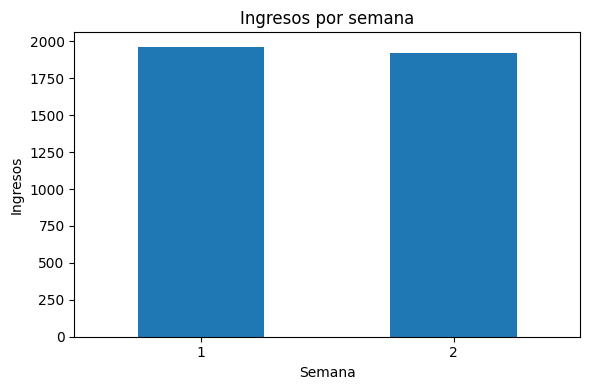

In [ ]:
# Paso 10: Comparación semanal de ingresos
weekly_summary['Ingresos'].plot(
    kind='bar',
    figsize=(6, 4),
    title='Ingresos por semana'
)

plt.xlabel('Semana')
plt.ylabel('Ingresos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Exploración autónoma: una visualización adicional

Hasta este punto ha utilizado dos visualizaciones proporcionadas en el notebook. Ahora debe producir **una tercera visualización** que considere útil para apoyar una recomendación del informe ejecutivo.

Puede explorar, por ejemplo:

- recurrencia de clientes;
- ingresos por ocupación;
- registros de venta por semana;
- ingreso promedio por registro;
- comparación entre dos indicadores del menú.

### Requisitos

1. Utilice `matplotlib` o las funciones de gráfico de `pandas`.
2. Incluya título y etiquetas claras.
3. No muestre nombres de clientes.
4. Debajo del gráfico escriba **una frase** que explique por qué esa visualización aporta a una decisión del negocio.


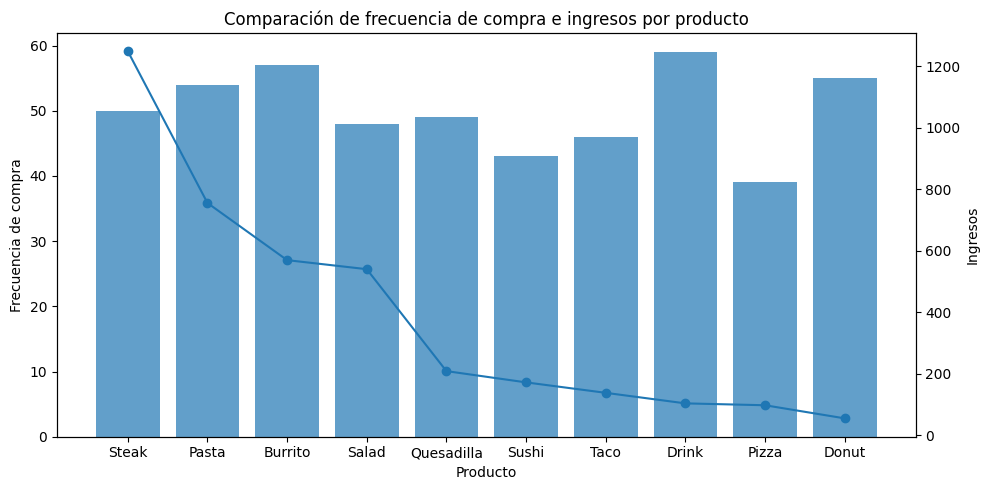

In [32]:
# Tercera visualización:
# Comparación entre frecuencia de compra e ingresos

fig, ax1 = plt.subplots(figsize=(10, 5))

# Frecuencia de compra
ax1.bar(
    top_foods.index,
    top_foods['Frecuencia_Compra'],
    alpha=0.7,
    label='Frecuencia de compra'
)

ax1.set_xlabel('Producto')
ax1.set_ylabel('Frecuencia de compra')
ax1.tick_params(axis='x', rotation=0)

# Segundo eje para ingresos
ax2 = ax1.twinx()

ax2.plot(
    top_foods.index,
    top_foods['Ingresos_Totales'],
    marker='o',
    label='Ingresos totales'
)

ax2.set_ylabel('Ingresos')

plt.title('Comparación de frecuencia de compra e ingresos por producto')

fig.tight_layout()
plt.show()

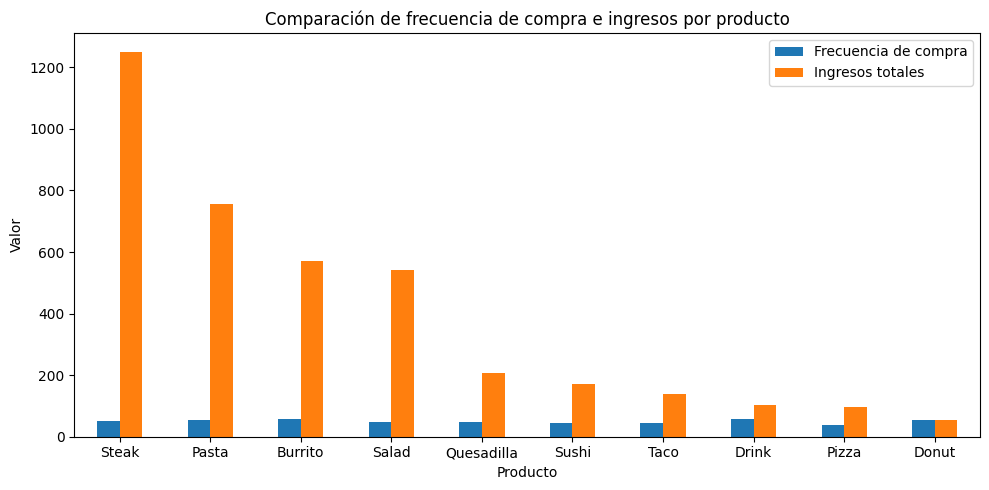

In [33]:
# TODO: construya aquí una tercera visualización de su elección

# Ejemplo de estructura:
# datos_para_grafico = ...
# datos_para_grafico.plot(...)
# plt.title('...')
# plt.xlabel('...')
# plt.ylabel('...')
# plt.tight_layout()
# plt.show()
# Tercera visualización: comparación entre dos indicadores del menú

datos_para_grafico = top_foods[['Frecuencia_Compra', 'Ingresos_Totales']]

ax = datos_para_grafico.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Comparación de frecuencia de compra e ingresos por producto')
plt.xlabel('Producto')
plt.ylabel('Valor')
plt.xticks(rotation=0)

plt.legend(['Frecuencia de compra', 'Ingresos totales'])

plt.tight_layout()
plt.show()

**¿Por qué esta visualización es útil para la toma de decisiones?**  

Escriba aquí una frase de interpretación.


R/T:Esta visualización permite comparar la frecuencia de compra con los ingresos generados por cada producto y ayuda a identificar cuáles productos tienen mayor demanda y cuáles aportan más ingresos al negocio.

## 7. Análisis

Responda brevemente en una celda de texto antes de elaborar el informe ejecutivo:

1. ¿El producto con mayor frecuencia de compra es también el de mayores ingresos?
No. El Burrito tiene la mayor frecuencia de compra, con 57 registros, mientras que el Steak genera los mayores ingresos, con 1249.50. Esto muestra que el producto que se compra con mayor frecuencia no necesariamente es el que genera más ingresos.

2. ¿Qué cambió entre las semanas en ingresos, registros de venta e ingreso promedio por registro?
Los registros de venta se mantuvieron iguales, con 250 registros en cada semana. Los ingresos disminuyeron de 1962.68 en la semana 1 a 1923.88 en la semana 2. El ingreso promedio por registro también disminuyó ligeramente, pasando de aproximadamente 7.85 a 7.70.

3. ¿Qué porcentaje de los clientes de la semana 1 volvió a aparecer en la semana 2?
El 20.8 % de los clientes de la semana 1 volvió a aparecer en la semana 2. Esto indica que aproximadamente una quinta parte de los clientes registrados en la primera semana también realizó una compra durante la segunda semana.

4. ¿Qué ocupaciones concentran más ingresos en los datos observados?
Las ocupaciones que concentran más ingresos son Compensation Analyst (116.68), Sales Representative (104.18), Marketing Manager (99.40), Cost Accountant (80.21) y Assistant Media Planner (72.69). Estos valores representan los ingresos acumulados de los clientes pertenecientes a cada ocupación.

5. ¿Qué información adicional necesitaría para explicar las diferencias encontradas?
Sería necesario contar con información sobre cantidades vendidas, costos de los productos, descuentos y promociones, además de datos de un período más largo. Esta información permitiría analizar mejor las diferencias observadas. Con los datos disponibles podemos identificar asociaciones y diferencias, pero no podemos demostrar causalidad.

> **Importante:** describa asociaciones y diferencias observadas. Con estos datos no puede demostrar causalidad.

### Escriba aquí su análisis

**1. Desempeño del menú:**

El Burrito presentó la mayor frecuencia de compra, con 57 registros, mientras que el Steak obtuvo los mayores ingresos, con 1249.50. Esto muestra que el producto con mayor frecuencia de compra no necesariamente es el que genera mayores ingresos.

**2. Comparación semanal:**

Los registros de venta fueron iguales en las dos semanas, con 250 registros en cada una. Sin embargo, los ingresos disminuyeron de 1962.68 en la semana 1 a 1923.88 en la semana 2. El ingreso promedio por registro también presentó una disminución, pasando aproximadamente de 7.85 a 7.70.

**3. Recurrencia:**

La tasa de recurrencia fue del 20.8 %, lo que significa que aproximadamente una quinta parte de los clientes de la semana 1 volvió a aparecer en la semana 2. Este resultado permite observar el nivel de recurrencia dentro del período analizado.

**4. Perfil agregado:**

Las ocupaciones que concentraron mayores ingresos fueron Compensation Analyst, Sales Representative, Marketing Manager, Cost Accountant y Assistant Media Planner. La primera presentó 116.68 en ingresos, seguida por 104.18, 99.40, 80.21 y 72.69, respectivamente. Estos resultados corresponden a ingresos agregados por ocupación.

**5. Limitaciones de los datos:**

Los datos disponibles no incluyen información sobre cantidades vendidas, costos, descuentos o promociones. Además, solo se analizan dos semanas, por lo que no es suficiente para establecer tendencias de largo plazo ni determinar las causas de las diferencias observadas. Por esta razón, los resultados permiten identificar asociaciones y diferencias, pero no demostrar causalidad.

## 8. Conclusiones y recomendación

Redacte entre 3 y 5 conclusiones sustentadas en las cifras y gráficos obtenidos. Después formule una acción prioritaria para la siguiente semana de operación.

Evite:

- afirmar rentabilidad, utilidad o margen;
- atribuir causalidad a una variación de solo dos semanas;
- hacer afirmaciones sobre clientes individuales a partir de variables como ocupación o género.



1. El Burrito presentó la mayor frecuencia de compra con 57 registros, mientras que el Steak obtuvo los mayores ingresos con 1249.50, mostrando que frecuencia de compra e ingresos son indicadores diferentes.
2. Entre las dos semanas, los registros de venta se mantuvieron en 250, pero los ingresos disminuyeron de 1962.68 a 1923.88. El ingreso promedio por registro también bajó de aproximadamente 7.85 a 7.70.
3. La tasa de recurrencia fue del 20.8 %, por lo que una parte de los clientes registrados en la primera semana volvió a aparecer durante la segunda semana.

### Acción prioritaria para la siguiente semana

Realizar un seguimiento durante la próxima semana de los productos con mayor frecuencia de compra e ingresos, especialmente el Burrito y el Steak, y monitorear si se mantienen los niveles de ventas y la recurrencia observados. Con esta información se podrán tomar decisiones comerciales basadas en un período de observación más amplio, sin asumir causalidad a partir de solo dos semanas de datos.

## 9. Evidencia del laboratorio

Para la entrega del laboratorio:

1. conserve este notebook ejecutado;
2. incluya el notebook y un `README.md` en su repositorio;
3. el README debe indicar objetivo, archivos utilizados, instrucciones y hallazgos;
4. no publique nombres de clientes ni el archivo de clientes en un repositorio público;
5. elabore el *One-Page Executive Report* de acuerdo con la guía del laboratorio.